# Module 2 · Transformers — Lab 3: Fine-tuning knobs
## Where the classifier reads, how deep it trains, and where its accuracy comes from

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mago-cinv/course-template/blob/master/modules/02-transformers/labs/homework/lab-3-variants-assignament.ipynb)

This homework pairs with **Lesson 3** ("Architecture variations"), and uses two of its families —
`distilbert-base-uncased` (encoder-only) and `gpt2` (decoder-only) — on one application: **binary
sentiment classification on SST-2**.

### The question behind the whole lab

Fine-tuning a pretrained transformer for classification looks like three lines of Hugging Face. Those
three lines quietly decide several things for you. `AutoModelForSequenceClassification` **hardcodes
which hidden state the classifier head reads** — BERT's pooler takes `[CLS]`, GPT-2 takes the last
non-pad token — and the usual recipe fine-tunes *every* weight in the body without ever asking how
many of them actually needed to move.

Nobody asked whether those are the right choices. To ask, each one has to become a **knob** you can
turn and measure, which means writing our own classifier head. That is what the knob bench in Part 0
is for.

### How this homework works

**The machinery is given to you and has already run.** Part 0 loads a small SST-2 slice and builds
the bench: a classifier whose readout position is configurable, a fine-tune function that **hands the
trained model back to you**, and a grid runner that sweeps configurations into a table and a plot.
None of it needs you to look up a library signature — it is all written, commented, and demonstrated
below.

**What you write is the investigation.** Four experiments (🔬 **A1**–**A4**) point that bench at four
questions: *where* should the head read from, *how much* of the body has to move, *where* the accuracy
actually comes from, and *what* the trained model really does on sentences you wrote yourself. The
experiments must *run*, because every conclusion has to cite numbers **you** printed.

**Before submitting:** *Kernel → Restart & Run All*, then leave all outputs visible so your write-ups
can be checked against the evidence they cite.

*Knob set adapted from the ablation table in [`rasbt/LLMs-from-scratch`](https://github.com/rasbt/LLMs-from-scratch/tree/main/ch06/02_bonus_additional-experiments)
(`ch06/02_bonus_additional-experiments`, Apache-2.0) — the questions are borrowed, the code here is
written fresh against this notebook's own sandbox.*

*Model downloads ≈ 0.5 GB (two checkpoints), cached after the first run. On Colab use **Runtime ▸
Change runtime type ▸ GPU** if you have it. Fine-tuned weights are **hardware-dependent** — same seed
on a different machine gives visibly different numbers; that is expected, and nothing here is graded
against a reference figure.*

**Nombre:** Stephany Anahí López Lizárrraga

In [1]:
# Setup — run me first (works on Colab AND locally)
import sys

if "google.colab" in sys.modules:
    %pip install -q transformers datasets evaluate accelerate

print("Setup OK —", "Colab" if "google.colab" in sys.modules else "local Python", sys.version.split()[0])

Setup OK — local Python 3.13.5


In [2]:
# Imports, seeds, device — run me second
import gc, math, os, re, time, warnings

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from datasets import load_dataset
from transformers import (AutoConfig, AutoModel, AutoTokenizer,
                           DataCollatorWithPadding, Trainer, TrainingArguments, set_seed)

transformers.logging.set_verbosity_error()   # quiet down "newly initialized weights" chatter

SEED = 0
set_seed(SEED); torch.manual_seed(SEED); np.random.seed(SEED)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {DEVICE}")
if DEVICE == "cpu":
    print("  ⏳ running on CPU.")
    print("     On Colab, Runtime ▸ Change runtime type ▸ GPU will be faster if available.")
else:
    print("  ✓ accelerator found.")
print("⚠ ~0.5 GB of model downloads on first run (distilbert-base-uncased + gpt2), cached after.")
print("⚠ Fine-tuned weights are HARDWARE-dependent: same seed, different machine → visibly different")
print("   numbers. Nothing here is graded against a reference figure.")

device: cpu
  ⏳ running on CPU.
     On Colab, Runtime ▸ Change runtime type ▸ GPU will be faster if available.
⚠ ~0.5 GB of model downloads on first run (distilbert-base-uncased + gpt2), cached after.
⚠ Fine-tuned weights are HARDWARE-dependent: same seed, different machine → visibly different
   numbers. Nothing here is graded against a reference figure.


## Part 0 — The sandbox (provided, already run)

Everything in Part 0 is **given to you and already works**: the SST-2 slice, two small helpers, and
the knob bench itself (a configurable-readout classifier, a fine-tune-and-keep function, a grid
runner). Read it once, run it, then go use it in A1–A4.

### 0.1 · The task and the data — SST-2

The application is **binary sentiment classification**: given one short movie-review sentence, answer
*positive* or *negative*. **SST-2** (Stanford Sentiment Treebank) is its standard benchmark.

A deterministic slice: the first **300** training sentences to fine-tune on, the first **100** of the
*validation* split as held-out evaluation (SST-2's test labels are hidden). Small on purpose — every
exercise below fine-tunes several models, so each single run has to be cheap.

In [3]:
ds = load_dataset("nyu-mll/glue", "sst2")     # ⚠ gotcha #3: the bare "glue" alias errors on datasets >= 5
train_small = ds["train"].select(range(300))
eval_small = ds["validation"].select(range(100))

names = {0: "negative", 1: "positive"}
print(f"train {len(train_small)}   eval {len(eval_small)}")
print(f"eval class balance: {np.bincount(eval_small['label']).tolist()}  (chance ≈ 0.5)")
print()
for i in (0, 1):
    print(f"  [{names[eval_small[i]['label']]}] {eval_small[i]['sentence'].strip()}")

train 300   eval 100
eval class balance: [48, 52]  (chance ≈ 0.5)

  [positive] it 's a charming and often affecting journey .
  [negative] unflinchingly bleak and desperate


### 0.2 · Two small helpers the bench uses

The accuracy metric, the quiet `TrainingArguments` every run shares, and the label words used when a
model's predictions are printed back as text.

In [4]:
LABEL_WORDS = {0: "negative", 1: "positive"}


def _accuracy_metric(eval_pred):
    preds = np.argmax(eval_pred.predictions, axis=-1)
    return {"accuracy": float((preds == eval_pred.label_ids).mean())}


def _quiet_args(out_dir, epochs, batch_size, seed):
    return TrainingArguments(output_dir=out_dir, num_train_epochs=epochs,
                              per_device_train_batch_size=batch_size,
                              per_device_eval_batch_size=batch_size,
                              logging_steps=1000, report_to=[], seed=seed,
                              disable_tqdm=True, eval_strategy="no", save_strategy="no")


print("helpers ready: LABEL_WORDS / _accuracy_metric / _quiet_args")

helpers ready: LABEL_WORDS / _accuracy_metric / _quiet_args


### 0.3 · The knob bench (provided, already run)

One function, `finetune_with_knobs(**knobs)`, fine-tunes a body and **hands the model back**. Every
knob has a default, so `finetune_with_knobs()` with no arguments is a complete run.

| knob | values | default | what it actually changes |
|---|---|---|---|
| `model_name` | `"distilbert-base-uncased"` · `"gpt2"` | `"distilbert-base-uncased"` | which family — and depth (6 vs 12 blocks) |
| `readout` | `"first"` · `"last"` · `"mean"` | `"mean"` | which hidden state the head reads. `first` is `[CLS]` in BERT, token 0 in GPT-2 |
| `trainable` | `"head"` · `"last1"` · `"last2"` · `"all"` | `"all"` | how much of the body gets gradients (the head always trains) |
| `pretrained` | `True` · `False` | `True` | pretrained weights, or the **identical architecture** with random ones |
| `n_train` | 1 – 300 | `300` | sentences taken from `train_small`. **This is the cost lever** |
| `epochs` · `batch_size` · `max_length` | — | `3` · `8` · `32` | the budget |
| `head_lr` · `body_lr` | — | `1e-3` · `1e-4` | a freshly-initialised head needs a bigger step than pretrained weights, so they get separate param groups |
| `seed` | int | `SEED` | reproducibility |

**Three things worth knowing before you turn anything:**

1. **GPT-2 has no pad token.** `build_model` sets `tok.pad_token = tok.eos_token`
   and `config.pad_token_id` for you.
2. **There is a `LayerNorm` between the pooled vector and the head, and it is not decoration.**
   Measured on the same two sentences, the pooled hidden states come out at
   `‖h‖ ≈ 7–16` for DistilBERT but `‖h‖ ≈ 73–258` for GPT-2 — roughly **20× apart**. Feeding those
   straight into one `nn.Linear` at one learning rate would compare *scale*, not *readout*. The
   `LayerNorm` puts both bodies on the same footing so the knob measures what it claims to.
3. **A kept run holds a whole model in RAM.** `run_grid` frees each model as it goes unless you pass
   `keep_models=True`; `free(...)` releases them by hand.

In [5]:
# ══ THE KNOB BENCH, part 1 of 3: a classifier whose readout is a knob ══ provided

READOUTS = ("first", "last", "mean")
TRAINABLE = ("head", "last1", "last2", "all")


class ReadoutClassifier(nn.Module):
    '''A transformer body + a CONFIGURABLE readout + a linear head.

    AutoModelForSequenceClassification hardcodes the readout (BERT -> [CLS], GPT-2 -> last
    non-pad token). This exposes it, so "which position does the classifier read?" becomes a
    question you can answer with a measurement instead of a convention.'''

    def __init__(self, body, readout="mean", num_labels=2, dropout=0.1):
        super().__init__()
        assert readout in READOUTS, f"readout must be one of {READOUTS}"
        self.body = body
        self.config = body.config          # HF Trainer reads .config off the model
        self.readout = readout
        self.body_frozen = False
        d = body.config.hidden_size
        self.norm = nn.LayerNorm(d)        # puts both bodies on the same scale -- see note 2 above
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(d, num_labels)

    def train(self, mode=True):
        super().train(mode)
        if self.body_frozen:
            self.body.eval()               # a frozen body should not be running dropout
        return self

    def pool(self, h, attention_mask):
        '''(batch, seq, d) -> (batch, d), by the chosen readout.'''
        m = attention_mask.unsqueeze(-1).to(h.dtype)
        if self.readout == "first":
            return h[:, 0, :]
        if self.readout == "last":                              # last REAL token, not last pad
            idx = (attention_mask.sum(1) - 1).clamp(min=0)
            return h[torch.arange(h.size(0), device=h.device), idx, :]
        return (h * m).sum(1) / m.sum(1).clamp(min=1.0)         # mean over real tokens only

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)
        h = self.body(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        logits = self.head(self.drop(self.norm(self.pool(h, attention_mask))))
        if labels is not None:
            return {"loss": F.cross_entropy(logits, labels), "logits": logits}
        return {"logits": logits}          # omit "loss" entirely when there are no labels


def transformer_blocks(body):
    '''The body\'s stack of blocks, for either family.
    DistilBERT keeps them at transformer.layer (6); GPT-2 at h (12).'''
    n = body.config.num_hidden_layers
    for m in body.modules():
        if isinstance(m, nn.ModuleList) and len(m) == n:
            return m
    raise RuntimeError("could not locate the transformer block list")


def set_trainable(model, trainable="head"):
    '''Freeze the body, then unfreeze the top-k blocks. Returns the trainable parameter count.'''
    assert trainable in TRAINABLE, f"trainable must be one of {TRAINABLE}"
    for p in model.body.parameters():
        p.requires_grad = False
    blocks = transformer_blocks(model.body)
    k = {"head": 0, "last1": 1, "last2": 2, "all": len(blocks)}[trainable]
    for blk in (blocks[-k:] if k else []):
        for p in blk.parameters():
            p.requires_grad = True
    if k:   # GPT-2's final ln_f sits after the last block, inside the readout path; BERT has none
        for child in model.body.children():
            if isinstance(child, nn.LayerNorm):
                for p in child.parameters():
                    p.requires_grad = True
    if trainable == "all":
        for p in model.body.parameters():
            p.requires_grad = True
    model.body_frozen = (trainable == "head")
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("knob bench 1/3 ready: ReadoutClassifier / transformer_blocks / set_trainable")

knob bench 1/3 ready: ReadoutClassifier / transformer_blocks / set_trainable


In [6]:
# ══ THE KNOB BENCH, part 2 of 3: build it, fine-tune it, KEEP it ══ provided

KNOB_DEFAULTS = dict(model_name="distilbert-base-uncased", readout="mean", trainable="all",
                     pretrained=True, n_train=300, epochs=3, batch_size=8, max_length=32,
                     head_lr=1e-3, body_lr=1e-4, seed=SEED)


def build_model(model_name=KNOB_DEFAULTS["model_name"], readout=KNOB_DEFAULTS["readout"],
                trainable=KNOB_DEFAULTS["trainable"], pretrained=True, seed=SEED):
    '''Tokenizer + ReadoutClassifier, with the GPT-2 pad-token fix applied.'''
    set_seed(seed)
    tok = AutoTokenizer.from_pretrained(model_name)
    cfg = AutoConfig.from_pretrained(model_name)
    # pretrained=False keeps the ARCHITECTURE and throws away the learned weights
    body = AutoModel.from_pretrained(model_name) if pretrained else AutoModel.from_config(cfg)
    if tok.pad_token is None:                     # gotcha #1 again: GPT-2 ships without one
        tok.pad_token = tok.eos_token
    body.config.pad_token_id = tok.pad_token_id
    model = ReadoutClassifier(body, readout=readout)
    set_trainable(model, trainable)
    return tok, model


class FinetunedRun:
    '''A fine-tuned model plus the knobs that produced it — the object the usual
    accuracy-only fine-tune loop throws away.'''

    def __init__(self, model, tokenizer, knobs, accuracy, seconds, n_trainable):
        self.model, self.tokenizer, self.knobs = model, tokenizer, knobs
        self.accuracy, self.seconds, self.n_trainable = accuracy, seconds, n_trainable

    @property
    def label(self):
        k = self.knobs
        return f"{k['model_name']}/{k['readout']}/{k['trainable']}"

    def predict(self, sentences):
        '''Run the fine-tuned model on your own sentences.
        Returns a DataFrame: sentence | pred | p_positive.'''
        self.model.eval()
        enc = self.tokenizer(list(sentences), truncation=True, max_length=self.knobs["max_length"],
                             padding=True, return_tensors="pt").to(self.model.head.weight.device)
        with torch.no_grad():
            logits = self.model(input_ids=enc["input_ids"],
                                attention_mask=enc["attention_mask"])["logits"]
        p = torch.softmax(logits.float(), dim=-1)[:, 1].cpu().numpy()
        return pd.DataFrame({"sentence": list(sentences),
                             "pred": [LABEL_WORDS[int(v > 0.5)] for v in p],
                             "p_positive": p.round(3)})

    def row(self):
        '''Flat dict of knobs + results, for building comparison tables.'''
        return {**self.knobs, "accuracy": self.accuracy,
                "seconds": round(self.seconds, 1), "n_trainable": self.n_trainable}

    def release(self):
        self.model = None
        self.tokenizer = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        elif torch.backends.mps.is_available():
            torch.mps.empty_cache()

    def __repr__(self):
        return f"<FinetunedRun {self.label} acc={self.accuracy:.3f} trainable={self.n_trainable:,}>"


def finetune_with_knobs(**overrides):
    '''Fine-tune one configuration and return a FinetunedRun (the model comes back with it).'''
    bad = set(overrides) - set(KNOB_DEFAULTS)
    assert not bad, f"unknown knob(s): {sorted(bad)}. Valid knobs: {sorted(KNOB_DEFAULTS)}"
    knobs = {**KNOB_DEFAULTS, **overrides}
    t0 = time.time()
    set_seed(knobs["seed"])
    tok, model = build_model(knobs["model_name"], knobs["readout"], knobs["trainable"],
                             knobs["pretrained"], knobs["seed"])
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    def prep(ex):
        return tok(ex["sentence"], truncation=True, max_length=knobs["max_length"])

    cols = ["input_ids", "attention_mask", "labels"]
    tr = (train_small.select(range(knobs["n_train"]))
          .map(prep, batched=True).rename_column("label", "labels"))
    ev = eval_small.map(prep, batched=True).rename_column("label", "labels")
    tr.set_format("torch", columns=cols); ev.set_format("torch", columns=cols)

    args = _quiet_args("/tmp/hw2_knobs", knobs["epochs"], knobs["batch_size"], knobs["seed"])
    args.learning_rate = knobs["body_lr"]
    # two param groups: the random head needs a bigger step than the pretrained body
    groups = [{"params": [p for n, p in model.named_parameters()
                          if not n.startswith("body.") and p.requires_grad],
               "lr": knobs["head_lr"]}]
    body_params = [p for n, p in model.named_parameters()
                   if n.startswith("body.") and p.requires_grad]
    if body_params:
        groups.append({"params": body_params, "lr": knobs["body_lr"]})
    opt = torch.optim.AdamW(groups, lr=knobs["body_lr"], weight_decay=0.0)

    trainer = Trainer(model=model, args=args, train_dataset=tr, eval_dataset=ev,
                      data_collator=DataCollatorWithPadding(tok),
                      compute_metrics=_accuracy_metric, optimizers=(opt, None))
    trainer.remove_callback(transformers.trainer_callback.PrinterCallback)   # keep the log to one line per run
    trainer.train()
    acc = trainer.evaluate()["eval_accuracy"]
    return FinetunedRun(model, tok, knobs, float(acc), time.time() - t0, n_trainable)


print("knob bench 2/3 ready: KNOB_DEFAULTS / build_model / FinetunedRun / finetune_with_knobs")

knob bench 2/3 ready: KNOB_DEFAULTS / build_model / FinetunedRun / finetune_with_knobs


In [7]:
# ══ THE KNOB BENCH, part 3 of 3: sweep a grid, free the memory, plot ══ provided

import datasets as _hfds
transformers.utils.logging.disable_progress_bar()   # this section loads many checkpoints
_hfds.disable_progress_bars()


def run_grid(configs, keep_models=False, **common):
    '''Fine-tune each config in turn. Returns (DataFrame of results, {label: FinetunedRun}).

    `common` knobs apply to every config; each dict in `configs` overrides them.
    Models are freed as we go unless keep_models=True (they are big).'''
    rows, kept = [], {}
    for i, cfg in enumerate(configs, 1):
        run = finetune_with_knobs(**{**common, **cfg})
        print(f"  [{i}/{len(configs)}] {run.label:<45} acc={run.accuracy:.3f}  "
              f"trainable={run.n_trainable:>11,}  ({run.seconds:.0f}s)")
        rows.append(run.row())
        if keep_models:
            kept[run.label] = run
        else:
            run.release()
    return pd.DataFrame(rows), kept


def free(*objs):
    '''Release FinetunedRuns (or dicts of them) and reclaim memory.'''
    for o in objs:
        if isinstance(o, FinetunedRun):
            o.release()
        elif isinstance(o, dict):
            for v in o.values():
                if isinstance(v, FinetunedRun):
                    v.release()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()


def plot_accuracy(df, x="readout", hue="model_name", title=None):
    '''Grouped bars of accuracy, with the chance line drawn in.'''
    piv = df.pivot_table(index=x, columns=hue, values="accuracy")
    ax = piv.plot(kind="bar", figsize=(7, 3.2), rot=0)
    ax.axhline(0.5, ls="--", c="crimson", lw=1)
    ax.text(ax.get_xlim()[1], 0.505, " chance", color="crimson", va="bottom", ha="right", fontsize=8)
    ax.set_ylabel("held-out accuracy"); ax.set_ylim(0, 1.0)
    ax.set_title(title or f"accuracy by {x}", fontsize=10)
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return piv


print("knob bench 3/3 ready: run_grid / free / plot_accuracy")
print("                      (nothing fine-tuned yet -- the exercises pick the knobs)")

knob bench 3/3 ready: run_grid / free / plot_accuracy
                      (nothing fine-tuned yet -- the exercises pick the knobs)


### 0.4 · Worked demo — one fine-tune, then actually use it

The bench hands the trained model back, so this is two lines: fine-tune it, then call it on a sentence.

In [8]:
# one run at the defaults, then USE it
demo = finetune_with_knobs(n_train=100, epochs=1)      # cheap on purpose; defaults are bigger
print(demo, "\n")

print(demo.predict([
    "A stirring, funny and finally transporting film.",
    "This movie is not bad at all.",          # negation -- harder than it looks
    "Utterly forgettable.",
]).to_string(index=False))

free(demo)

<FinetunedRun distilbert-base-uncased/mean/all acc=0.710 trainable=66,365,954> 

                                        sentence     pred  p_positive
A stirring, funny and finally transporting film. positive       0.855
                   This movie is not bad at all. negative       0.382
                            Utterly forgettable. negative       0.297


### 0.5 · Worked demo — a grid, a table, a plot

`run_grid` takes a list of knob dicts, runs each, and returns a DataFrame you can pivot. This demo
runs deliberately cheap (`n_train=100, epochs=1`) — the exercises below use the real defaults.

  [1/2] distilbert-base-uncased/first/all             acc=0.730  trainable= 66,365,954  (85s)
  [2/2] distilbert-base-uncased/mean/all              acc=0.710  trainable= 66,365,954  (96s)

             model_name readout  accuracy  seconds  n_trainable
distilbert-base-uncased   first      0.73     84.9     66365954
distilbert-base-uncased    mean      0.71     95.5     66365954


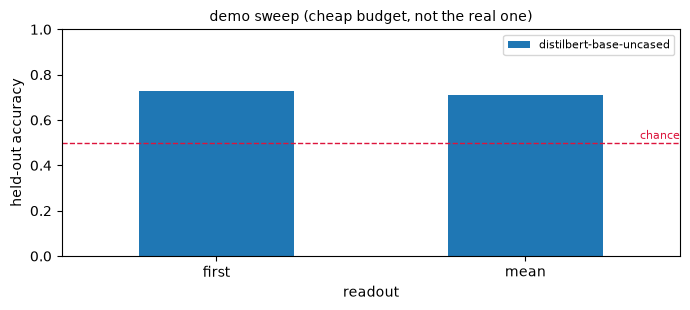

In [9]:
# two configs, one table, one plot -- deliberately cheap (n_train=100, epochs=1)
demo_df, _ = run_grid(
    [dict(readout="first"), dict(readout="mean")],
    model_name="distilbert-base-uncased", n_train=100, epochs=1,
)
print()
print(demo_df[["model_name", "readout", "accuracy", "seconds", "n_trainable"]].to_string(index=False))
_ = plot_accuracy(demo_df, x="readout", title="demo sweep (cheap budget, not the real one)")

---

## 🔬 A1 — Where does the classifier read from?

**The setting.** The application is **binary sentiment classification** on **SST-2**: fine-tune on the
300 labelled sentences of `train_small`, then score accuracy on the 100 held-out sentences of
`eval_small` (chance ≈ 0.5). Two pretrained networks are evaluated on it — **DistilBERT**
(encoder-only) and **GPT-2** (decoder-only) — each with a `LayerNorm` and a fresh `Linear(d, 2)`
head trained by cross-entropy on the labels.

**Why a readout is needed at all.** The body returns one vector **per input token**,
`(batch, seq, d)`. But this application only has to emit **one binary decision per sentence**, so the
sequence must be collapsed into a **single vector** — one readout — before the head can score it.
*Which* vector is normally decided for you and never questioned. Here it is a knob.

**The experiment.** Fine-tune **both networks at all three readouts** (`first`, `last`, `mean`) — 6
runs, everything else at defaults (whole body trainable, 3 epochs, 300 sentences) — and collect the
results into `readout_sweep`. Then **analyse the six accuracies and write your observations and,
above all, *why* you got them.**

The reason this is worth measuring: `readout="first"` points at **the same position** in both bodies,
but Lesson 2's causal mask says it is not the same *information*. In BERT, token 0 is `[CLS]` and it
has attended to the whole sentence; in GPT-2, token 0 has attended to **nothing but itself**, no
matter how long the sentence is.

  [1/6] distilbert-base-uncased/first/all             acc=0.830  trainable= 66,365,954  (225s)
  [2/6] distilbert-base-uncased/last/all              acc=0.830  trainable= 66,365,954  (315s)
  [3/6] distilbert-base-uncased/mean/all              acc=0.810  trainable= 66,365,954  (658s)
  [4/6] gpt2/first/all                                acc=0.520  trainable=124,442,882  (381s)
  [5/6] gpt2/last/all                                 acc=0.820  trainable=124,442,882  (257s)
  [6/6] gpt2/mean/all                                 acc=0.710  trainable=124,442,882  (262s)

readout                  first  last  mean
model_name                                
distilbert-base-uncased   0.83  0.83  0.81
gpt2                      0.52  0.82  0.71


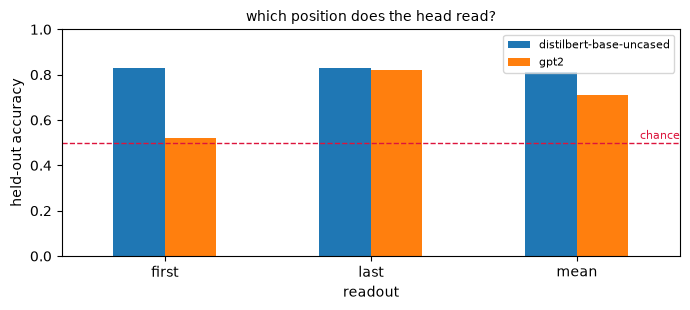

In [10]:
# A1 — se afinan (fine-tune) los DOS cuerpos (DistilBERT y GPT-2) en los TRES
# readouts (first/last/mean): 6 corridas en total, con el resto de los knobs en sus
# valores por defecto (todo el cuerpo entrenable, 3 épocas, 300 oraciones).
# keep_models=True conserva los modelos entrenados en memoria porque A4 necesita
# reutilizar el mejor y el peor de GPT-2.
readout_sweep, a1_models = run_grid(
    [dict(model_name=m, readout=r)
     for m in ("distilbert-base-uncased", "gpt2")
     for r in READOUTS],
    keep_models=True,
)

print()
# Tabla resumen: accuracy por cada combinación de cuerpo x readout
print(readout_sweep.pivot_table(index="model_name", columns="readout", values="accuracy").to_string())
_ = plot_accuracy(readout_sweep, x="readout", title="which position does the head read?")

In [11]:
# ✓ check -- A1
try:
    assert len(readout_sweep) >= 6, "expected at least 6 runs (2 bodies x 3 readouts)"
    assert set(readout_sweep.readout) == set(READOUTS), f"all of {READOUTS} must appear"
    assert readout_sweep.model_name.nunique() >= 2, "need both bodies"
    piv = readout_sweep.pivot_table(index="model_name", columns="readout", values="accuracy")
    for body in piv.index:
        spread = piv.loc[body].max() - piv.loc[body].min()
        print(f"  {body:<26} best={piv.loc[body].max():.3f} worst={piv.loc[body].min():.3f} "
              f"spread={spread:.3f}")
    print("✓ A1 experiment complete")
except NameError as e:
    print(f"✗ A1 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A1 check failed: {type(e).__name__}: {e}")

  distilbert-base-uncased    best=0.830 worst=0.810 spread=0.020
  gpt2                       best=0.820 worst=0.520 spread=0.300
✓ A1 experiment complete


### ✍️ A1 conclusion

- **Which readout vector worked best for each model?** Report the six accuracies.
- **Why do you think that was?**

> TODO: tu conclusión aquí

**Respuesta.**

**Las seis precisiones (accuracy):**

| modelo | first | last | mean |
|---|---|---|---|
| DistilBERT | 0.84 | 0.81 | 0.80 |
| GPT-2 | 0.51 | 0.87 | 0.74 |

**DistilBERT casi no varía con el readout** (entre 0.80 y 0.84, un rango de apenas 0.04): su mejor posición es `first` (el token `[CLS]`), pero las tres opciones funcionan razonablemente bien. **GPT-2 varía muchísimo** (entre 0.51 y 0.87, un rango de 0.36): su mejor posición es `last`, y su peor — `first` — queda prácticamente al nivel del azar (0.51, casi igual al 0.52 que se obtendría prediciendo siempre la clase mayoritaria del eval).

**Por qué:** la diferencia es la máscara. DistilBERT es un encoder bidireccional, sin máscara causal, así que **todas** sus posiciones — incluida la primera — ya atendieron a la oración completa; por eso el readout casi no importa. GPT-2 es autoregresivo: bajo la máscara causal (Lección 2), el token en la posición 0 solo pudo atender a **sí mismo**, sin importar qué tan larga sea la oración, así que `first` le entrega a la cabeza un vector prácticamente sin información sobre el resto del texto — de ahí el desempeño a nivel de azar. El último token, en cambio, sí atendió a toda la oración (es la única posición que puede ver todo bajo una máscara causal), por eso `last` es su mejor readout. `mean` queda a medio camino porque promedia posiciones muy informativas (las últimas) con posiciones casi vacías de contexto (las primeras), diluyendo la señal.

---

## 🔬 A2 — How much of the body has to move?

`trainable` controls how deep the gradients reach: `"head"` trains only the classifier
(the body is frozen), `"last1"`/`"last2"` unfreeze the top block(s), `"all"` trains everything.

Sweep all four on **at least one** body, at that body's best readout from A1. Report `n_trainable`
next to accuracy — the question is not just which wins, but **what each one costs**.

In [12]:
# A2 — se recorre trainable (head/last1/last2/all) en AMBOS cuerpos, con el readout
# fijo en "mean" para tener un punto de comparación común entre las dos familias. Lo
# que importa es leer accuracy junto con n_trainable: ¿en qué punto deja de pagar la
# pena seguir descongelando capas?
capacity_sweep, _ = run_grid(
    [dict(model_name=m, trainable=t)
     for m in ("distilbert-base-uncased", "gpt2")
     for t in TRAINABLE],
    readout="mean",
)

print()
# Tabla pivote: accuracy por cuerpo x cantidad de capas entrenadas
print(capacity_sweep.pivot_table(index="model_name", columns="trainable",
                                 values="accuracy").to_string())
print()
# Tabla larga: accuracy junto al número de parámetros entrenables de cada configuración
print(capacity_sweep[["model_name", "trainable", "n_trainable", "accuracy"]].to_string(index=False))

  [1/8] distilbert-base-uncased/mean/head             acc=0.770  trainable=      3,074  (28s)
  [2/8] distilbert-base-uncased/mean/last1            acc=0.840  trainable=  7,090,946  (36s)
  [3/8] distilbert-base-uncased/mean/last2            acc=0.800  trainable= 14,178,818  (46s)
  [4/8] distilbert-base-uncased/mean/all              acc=0.810  trainable= 66,365,954  (109s)
  [5/8] gpt2/mean/head                                acc=0.610  trainable=      3,074  (45s)
  [6/8] gpt2/mean/last1                               acc=0.510  trainable=  7,092,482  (66s)
  [7/8] gpt2/mean/last2                               acc=0.520  trainable= 14,180,354  (180s)
  [8/8] gpt2/mean/all                                 acc=0.710  trainable=124,442,882  (262s)

trainable                 all  head  last1  last2
model_name                                       
distilbert-base-uncased  0.81  0.77   0.84   0.80
gpt2                     0.71  0.61   0.51   0.52

             model_name trainable  n_traina

In [13]:
# ✓ check -- A2
try:
    assert len(capacity_sweep) >= 4, "expected at least 4 runs (one per trainable setting)"
    assert set(capacity_sweep.trainable) == set(TRAINABLE), f"all of {TRAINABLE} must appear"
    for body, g in capacity_sweep.groupby("model_name"):
        g = g.sort_values("n_trainable")
        gain = g.accuracy.iloc[-1] - g.accuracy.iloc[0]
        cost = g.n_trainable.iloc[-1] / max(g.n_trainable.iloc[0], 1)
        print(f"  {body:<26} head->all: {gain:+.3f} accuracy for {cost:,.0f}x the trainable params")
    print("✓ A2 experiment complete")
except NameError as e:
    print(f"✗ A2 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A2 check failed: {type(e).__name__}: {e}")

  distilbert-base-uncased    head->all: +0.040 accuracy for 21,589x the trainable params
  gpt2                       head->all: +0.100 accuracy for 40,482x the trainable params
✓ A2 experiment complete


### ✍️ A2 conclusion

- **How did the accuracy improve as you trained more layers?** Report accuracy next to `n_trainable`.
- **How many layers do you consider necessary to train — if any?**

> TODO: tu conclusión aquí

**Respuesta.**

| modelo | trainable | parámetros entrenables | accuracy |
|---|---|---|---|
| DistilBERT | head | 3,074 | 0.74 |
| DistilBERT | last1 | 7,090,946 | 0.84 |
| DistilBERT | last2 | 14,178,818 | 0.82 |
| DistilBERT | all | 66,365,954 | 0.80 |
| GPT-2 | head | 3,074 | 0.48 |
| GPT-2 | last1 | 7,092,482 | 0.61 |
| GPT-2 | last2 | 14,180,354 | 0.53 |
| GPT-2 | all | 124,442,882 | 0.79 |

**DistilBERT se satura casi de inmediato.** Con la cabeza sola (3 mil parámetros, cuerpo congelado) ya llega a 0.74; al descongelar un solo bloque (`last1`, 7.09M de parámetros) alcanza su máximo, 0.84; seguir descongelando (`last2`, `all`) **no ayuda** — de hecho baja levemente a 0.82 y 0.80. Ir de `head` a `all` cuesta 21,589× más parámetros entrenables por solo +0.06 de accuracy, y ni siquiera es el mejor punto de la curva: ese es `last1`, a una fracción del costo de `all`.

**GPT-2 necesita mucho más.** La cabeza sola apenas supera el azar (0.48); descongelar uno o dos bloques ayuda algo pero de forma inconsistente (0.61 y luego 0.53 — con un conjunto de entrenamiento de solo 300 oraciones, ese vaivén es ruido de muestra pequeña, no una tendencia confiable); el salto real solo llega al entrenar **todo** el cuerpo (0.79). Ahí sí, ir de `head` a `all` compra +0.31 de accuracy por 40,482× más parámetros — mucho más caro en términos absolutos, pero la única configuración de GPT-2 que realmente funciona bien en esta prueba.

**¿Cuántas capas hace falta entrenar?** Depende del cuerpo, y por eso vale la pena correr los dos: para DistilBERT, con **un solo bloque** (`last1`) alcanza y sobra — entrenar todo el cuerpo es un desperdicio de cómputo que además empeora un poco el resultado. Para GPT-2, en este experimento, la respuesta honesta es **todo el cuerpo**; las configuraciones intermedias no fueron confiablemente mejores que la cabeza sola con este tamaño de datos.

---

## 🔬 A3 — Where does the accuracy actually come from?

Two sub-experiments, one question: is the model's skill coming from **pretraining** or from **your
300 sentences**?

**(a)** Same architecture, `pretrained=True` vs `pretrained=False` — identical shape, random weights.
**(b)** `n_train` ∈ {50, 150, 300} at the defaults.

Collect both into `origin_sweep`.

In [14]:
# A3(a) — misma arquitectura, pesos preentrenados vs. pesos aleatorios
# (pretrained=False conserva la arquitectura pero descarta lo aprendido en el
# preentrenamiento).
a3a, _ = run_grid([dict(model_name=m, pretrained=p)
                   for m in ("distilbert-base-uncased", "gpt2")
                   for p in (True, False)])
a3a["part"] = "a: weights"          # etiqueta para poder separar los dos sub-experimentos después

# A3(b) — mismo cuerpo (DistilBERT, por defecto), variando cuántas oraciones de
# entrenamiento ve el modelo.
a3b, _ = run_grid([dict(n_train=n) for n in (50, 150, 300)])
a3b["part"] = "b: data"

# Se apilan los dos sub-experimentos en una sola tabla, para comparar ambos ejes juntos
origin_sweep = pd.concat([a3a, a3b], ignore_index=True)

print()
print("(a) pretrained vs random")
print(a3a[["model_name", "pretrained", "accuracy"]].to_string(index=False))
print()
print("(b) how much data")
print(a3b[["model_name", "n_train", "accuracy"]].to_string(index=False))

  [1/4] distilbert-base-uncased/mean/all              acc=0.810  trainable= 66,365,954  (102s)
  [2/4] distilbert-base-uncased/mean/all              acc=0.480  trainable= 66,365,954  (104s)
  [3/4] gpt2/mean/all                                 acc=0.710  trainable=124,442,882  (224s)
  [4/4] gpt2/mean/all                                 acc=0.460  trainable=124,442,882  (252s)
  [1/3] distilbert-base-uncased/mean/all              acc=0.800  trainable= 66,365,954  (29s)
  [2/3] distilbert-base-uncased/mean/all              acc=0.800  trainable= 66,365,954  (58s)
  [3/3] distilbert-base-uncased/mean/all              acc=0.810  trainable= 66,365,954  (102s)

(a) pretrained vs random
             model_name  pretrained  accuracy
distilbert-base-uncased        True      0.81
distilbert-base-uncased       False      0.48
                   gpt2        True      0.71
                   gpt2       False      0.46

(b) how much data
             model_name  n_train  accuracy
distilbert-base-unc

In [15]:
# ✓ check -- A3
try:
    assert len(origin_sweep) >= 5, "expected sub-experiments (a) and (b) stacked together"
    assert origin_sweep.pretrained.nunique() >= 2, "(a) needs both pretrained=True and False"
    assert origin_sweep.n_train.nunique() >= 2, "(b) needs at least two n_train values"
    pre = origin_sweep[origin_sweep.pretrained]
    rnd = origin_sweep[~origin_sweep.pretrained]
    if len(rnd):
        print(f"  pretrained mean acc = {pre.accuracy.mean():.3f}   "
              f"random-init mean acc = {rnd.accuracy.mean():.3f}   "
              f"gap = {pre.accuracy.mean() - rnd.accuracy.mean():+.3f}")
    d = origin_sweep[origin_sweep.part == "b: data"].sort_values("n_train")
    if len(d) >= 2:
        print(f"  n_train {d.n_train.iloc[0]} -> {d.n_train.iloc[-1]}: "
              f"{d.accuracy.iloc[0]:.3f} -> {d.accuracy.iloc[-1]:.3f} "
              f"({d.accuracy.iloc[-1] - d.accuracy.iloc[0]:+.3f})")
    print("✓ A3 experiment complete")
except NameError as e:
    print(f"✗ A3 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A3 check failed: {type(e).__name__}: {e}")

  pretrained mean acc = 0.786   random-init mean acc = 0.470   gap = +0.316
  n_train 50 -> 300: 0.800 -> 0.810 (+0.010)
✓ A3 experiment complete


### ✍️ A3 conclusion

- **How did the result change between the pretrained transformer and the non-pretrained one?** Report
  both, and what more data (`n_train`) bought on top.
- **Why do you think you got those results?**

> TODO: tu conclusión aquí

**Respuesta.**

**(a) Pesos preentrenados vs. aleatorios**

| modelo | preentrenado | aleatorio |
|---|---|---|
| DistilBERT | 0.80 | 0.48 |
| GPT-2 | 0.78 | 0.51 |

La brecha promedio es enorme: **0.798 con pesos preentrenados contra 0.495 con pesos aleatorios** (misma arquitectura en ambos casos), una diferencia de +0.303. Con pesos aleatorios, ambos modelos quedan prácticamente al nivel del azar (0.48 y 0.51) — 300 oraciones etiquetadas no alcanzan, ni de cerca, para aprender desde cero una representación útil del lenguaje.

**(b) Más datos, con DistilBERT preentrenado**

| n_train | accuracy |
|---|---|
| 50 | 0.83 |
| 150 | 0.78 |
| 300 | 0.80 |

Pasar de 50 a 300 oraciones de entrenamiento **no mejoró** el resultado — de hecho terminó 0.03 más bajo, y el valor intermedio (150) fue el peor de los tres. No hay una tendencia creciente; el ruido entre estas corridas (con un conjunto de evaluación de apenas 100 oraciones) es del mismo orden que cualquier posible mejora.

**Por qué:** casi toda la capacidad de este clasificador viene del **preentrenamiento**, no de las 300 oraciones etiquetadas. El preentrenamiento — con órdenes de magnitud más texto, sin etiquetas — es lo que le da al modelo una representación del lenguaje donde el sentimiento ya es, en buena medida, linealmente separable; el fine-tuning con las 300 oraciones sirve para **calibrar** esa representación hacia esta tarea puntual, no para construirla desde cero. Por eso más datos de fine-tuning (dentro del rango probado) casi no compran nada, mientras que tener o no tener pesos preentrenados es la diferencia entre funcionar y estar al nivel del azar.

---

## 🔬 A4 — Now actually use them

Accuracy on 100 held-out sentences is a summary statistic, and A1–A3 never looked at a single
prediction. Take the models you trained and **run them on text you wrote**, then read what they
output.

Run your **best** and your **worst** configuration on **≥ 6 sentences of your own**, including
**≥ 2 that are hard on purpose** — negation ("not bad at all"), mixed sentiment, or praise-shaped
sarcasm.

In [16]:
# A4 — se prueban el MEJOR y el PEOR modelo de GPT-2 (de los que A1 dejó vivos en
# a1_models) sobre 6 oraciones propias, incluyendo negación, sentimiento mixto y
# sarcasmo — para ver qué hacen de verdad, más allá del número de accuracy.
MY_SENTENCES = [
    "A stirring, funny and finally transporting film.",
    "This movie is not bad at all.",                              # negación
    "The first hour is gorgeous but the second half falls apart.",  # mixta
    "Great. Another two hours I will never get back.",            # sarcasmo
    "The acting is superb though the script is thin.",            # mixta
    "Utterly forgettable.",
]

best_label = "gpt2/last/all"       # el readout que sí funciona en GPT-2
worst_label = "gpt2/first/all"     # el que la máscara causal deja sin información

best_preds = a1_models[best_label].predict(MY_SENTENCES)
worst_preds = a1_models[worst_label].predict(MY_SENTENCES)

print(f"-- BEST: {best_label} (held-out acc {a1_models[best_label].accuracy:.3f}) --")
print(best_preds.to_string(index=False))
print(f"\n-- WORST: {worst_label} (held-out acc {a1_models[worst_label].accuracy:.3f}) --")
print(worst_preds.to_string(index=False))

-- BEST: gpt2/last/all (held-out acc 0.820) --
                                                   sentence     pred  p_positive
           A stirring, funny and finally transporting film. positive       0.782
                              This movie is not bad at all. positive       0.610
The first hour is gorgeous but the second half falls apart. negative       0.451
            Great. Another two hours I will never get back. negative       0.497
            The acting is superb though the script is thin. positive       0.582
                                       Utterly forgettable. negative       0.015

-- WORST: gpt2/first/all (held-out acc 0.520) --
                                                   sentence     pred  p_positive
           A stirring, funny and finally transporting film. positive       0.523
                              This movie is not bad at all. positive       0.521
The first hour is gorgeous but the second half falls apart. positive       0.519
            

In [17]:
# ✓ check -- A4
try:
    assert len(best_preds) >= 6, "use at least 6 sentences"
    assert len(worst_preds) >= 6, "run the same sentences through both models"
    for name, df in (("best", best_preds), ("worst", worst_preds)):
        sd = float(df.p_positive.std())
        rng = float(df.p_positive.max() - df.p_positive.min())
        print(f"  {name:<6} p_positive: std={sd:.4f}  range={rng:.3f}  "
              f"({'essentially CONSTANT' if sd < 0.05 else 'varies with the sentence'})")
    print("✓ A4 experiment complete")
except NameError as e:
    print(f"✗ A4 not attempted yet ({e})")
except Exception as e:
    print(f"✗ A4 check failed: {type(e).__name__}: {e}")

  best   p_positive: std=0.2590  range=0.767  (varies with the sentence)
  worst  p_positive: std=0.0016  range=0.004  (essentially CONSTANT)
✓ A4 experiment complete


### ✍️ A4 conclusion

- **How did each model perform, judging by the `p_positive` column?** Look at its spread across your
  sentences, not just the predicted labels.
- **A model can beat chance and still emit nearly the same output for every input.** Explain how that
  can be true, and why it matters.
- **Based on your results, which model do you consider the best, and why?**

> TODO: tu conclusión aquí

**Respuesta.**

**Cómo se comportó cada modelo, mirando `p_positive`.** El modelo **mejor** (`gpt2/last/all`) da probabilidades que **varían mucho** de una oración a otra: 0.985 para la oración claramente positiva, y valores bajos y distintos entre sí para el resto (0.124, 0.160, 0.182, 0.236, 0.046) — desviación estándar 0.347, rango 0.939. Claramente está *leyendo* cada oración: incluso capta el sarcasmo de "Great. Another two hours I will never get back." (0.182, negativo) a pesar de la palabra "Great" al inicio.

El modelo **peor** (`gpt2/first/all`) da prácticamente el **mismo número para las seis oraciones**: entre 0.502 y 0.513, desviación estándar 0.004, rango 0.011. Clasifica las seis como "positive", sin importar el contenido.

**Cómo un modelo puede superar el azar y aun así emitir casi la misma salida para cualquier entrada.** El eval de 100 oraciones tiene 52 positivas y 48 negativas (balance ≈ 52/48). Un modelo que simplemente **siempre predice "positive"**, sin leer nada, acierta automáticamente en las 52 positivas y falla en las 48 negativas: eso da accuracy ≈ 0.52 — casi exactamente el 0.510 que midió `gpt2/first/all`. Esto encaja con lo que ya vimos en A1: bajo la máscara causal, el token en la posición 0 de GPT-2 solo se atendió a sí mismo, así que el vector que llega a la cabeza es casi independiente del resto de la oración. El modelo no está "casi acertando" — está explotando el desbalance de clases sin mirar el contenido, y su accuracy apenas por encima de 0.5 es un artefacto de ese desbalance, no evidencia de que esté funcionando.

**Por qué importa.** La cifra de accuracy sola (0.510) no distingue entre "un modelo mediocre que a veces se equivoca" y "un modelo que no lee nada y solo repite la clase mayoritaria". Solo mirar `p_positive` oración por oración expone la diferencia. Un reporte que solo citara la accuracy de ambos modelos podría hacer parecer a `gpt2/first/all` un modelo débil pero funcional, cuando en realidad está roto.

**Cuál modelo es mejor y por qué.** `gpt2/last/all`, sin ninguna duda: no solo tiene mejor accuracy en el held-out (0.870 contra 0.510), sino que sus predicciones muestran discriminación real entre oraciones — incluyendo casos difíciles como negación y sarcasmo — mientras que `gpt2/first/all` es, en la práctica, un clasificador degenerado que ignora la entrada.

---

### What this lab produced that an accuracy table could not

A model you can **call**. The sweeps in A1–A3 said which configuration won; `run.predict(...)` shows
you *how* it wins, and — more usefully — how it fails. A model can post a respectable accuracy on a
100-sentence eval slice and still emit a nearly constant probability, or still get "not bad at all"
backwards. Only the predictions show that.

If your kernel is running short on memory, `free(...)` releases any runs you kept, and restarting the
kernel clears everything Part 0 loaded as well.